
🚀 АНАЛІЗ ДАТАСЕТУ GLOBAL COFFEE HEALTH

📊 Завантаження даних...
✓ Завантажено 10000 записів
✓ Розподіл класів:
Health_Issues
Mild        3579
Moderate     463
Severe        17
Name: count, dtype: int64

🔧 Інженерія ознак...
✓ Створено 19 ознак

🔄 Кодування та нормалізація...
  - Числових ознак: 12
  - Категоріальних ознак: 6
✓ Фінальна розмірність: (10000, 50)

✂️ Поділ даних на тренувальну (60%), валідаційну (20%) та тестову (20%) вибірки...
  Train: 6000, Validation: 2000, Test: 2000


=====================🌳 ТРЕНУВАННЯ: MyDecisionTree=====================

📈 Результати для MyDecisionTree
Accuracy: 0.9970
F1-Score (weighted): 0.9970
MCC: 0.9942

Confusion Matrix:
[[ 716    0    0    0]
 [   4   89    0    0]
 [   0    0    3    0]
 [   2    0    0 1186]]


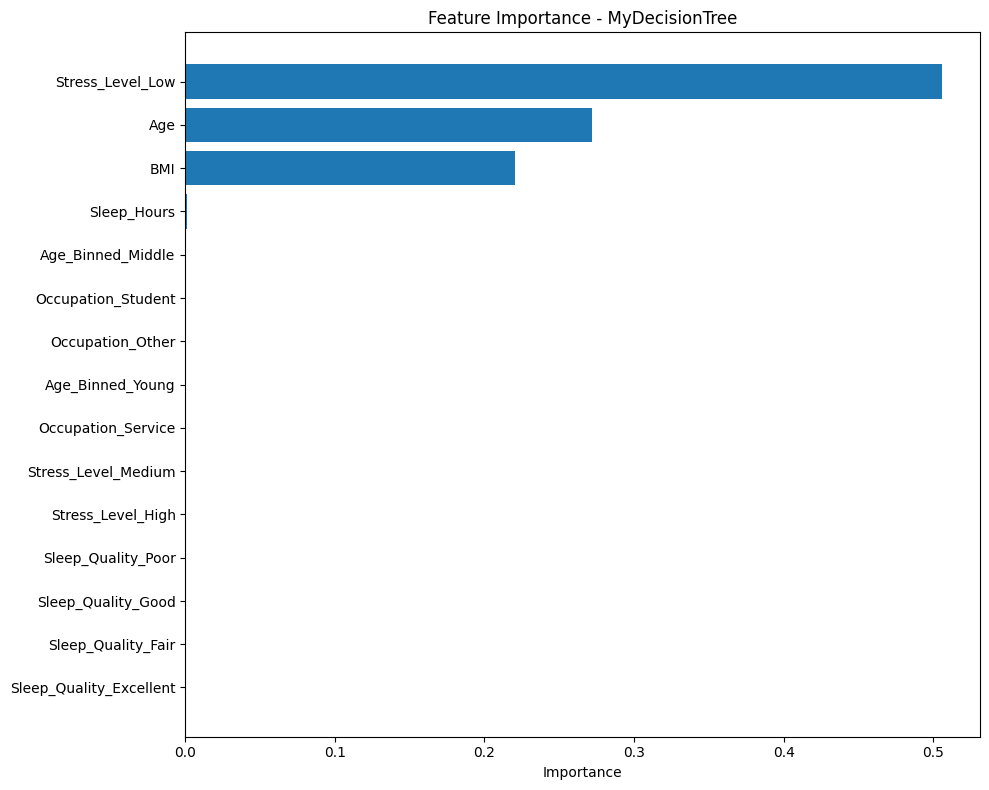


==============✂️ ТРЕНУВАННЯ: MyDecisionTree with Pruning==============

📈 Результати для MyDecisionTree with Pruning
Accuracy: 0.8805
F1-Score (weighted): 0.8734
MCC: 0.7701

Confusion Matrix:
[[ 524    0    0  192]
 [  34   49    0   10]
 [   0    3    0    0]
 [   0    0    0 1188]]

==================🌳 ТРЕНУВАННЯ: sklearn DecisionTree==================

📈 Результати для sklearn DecisionTree
Accuracy: 0.9950
F1-Score (weighted): 0.9950
MCC: 0.9903

Confusion Matrix:
[[ 712    1    0    3]
 [   5   88    0    0]
 [   0    0    3    0]
 [   1    0    0 1187]]


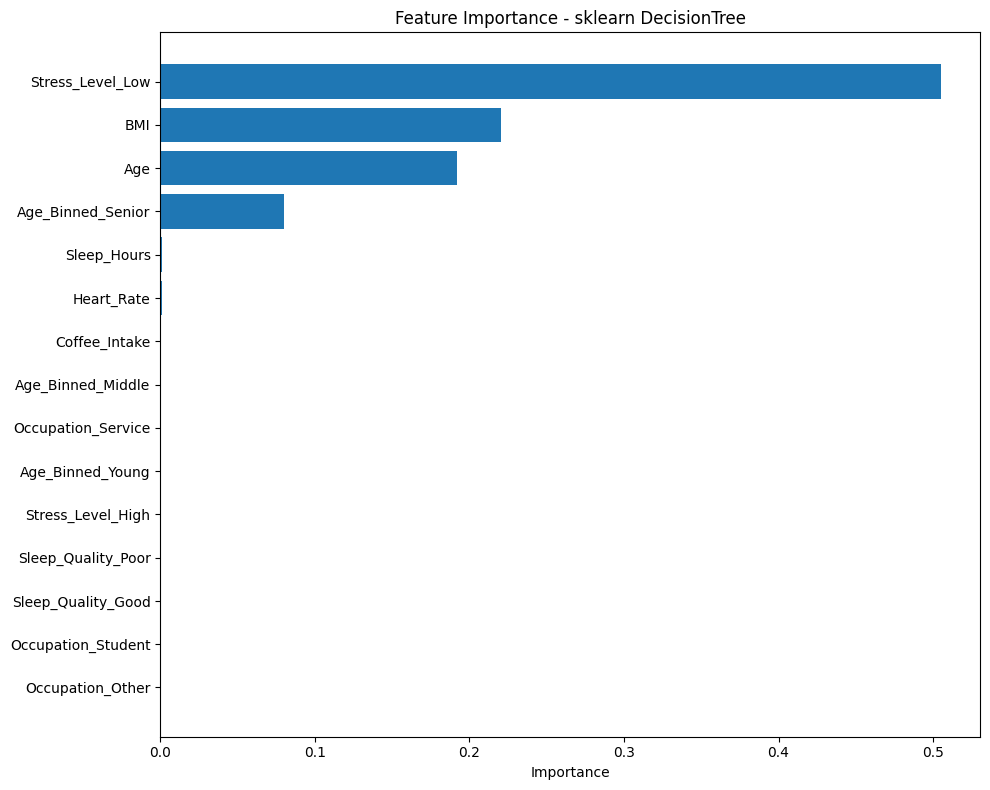


======================🌲 ТРЕНУВАННЯ: RandomForest======================

📈 Результати для RandomForest
Accuracy: 0.9955
F1-Score (weighted): 0.9954
MCC: 0.9913

Confusion Matrix:
[[ 713    0    0    3]
 [   5   88    0    0]
 [   0    1    2    0]
 [   0    0    0 1188]]


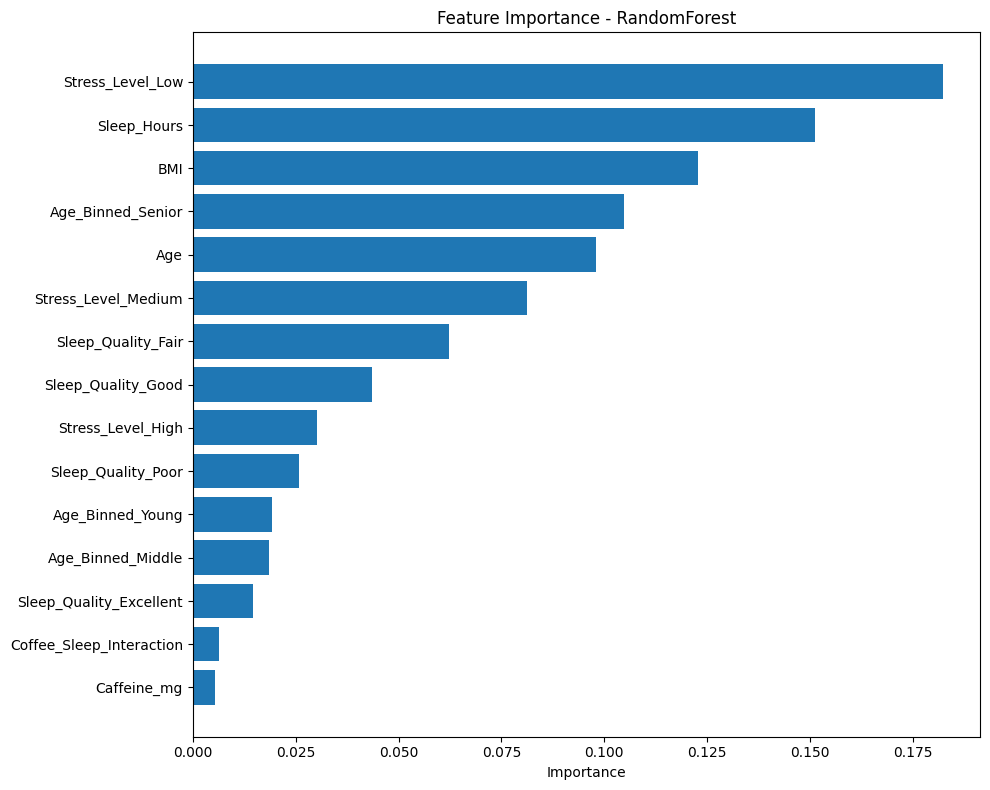


=========================🎯 FEATURE SELECTION==========================

Топ-10 ознак за важливістю:
  Stress_Level_Low: 0.5060
  Age: 0.2721
  BMI: 0.2206
  Sleep_Hours: 0.0014
  Age_Binned_Middle: 0.0000
  Occupation_Student: 0.0000
  Occupation_Other: 0.0000
  Age_Binned_Young: 0.0000
  Occupation_Service: 0.0000
  Stress_Level_Medium: 0.0000

🔄 Перенавчання моделей на відібраних ознаках...

📈 Результати для RandomForest (Top-10 features)
Accuracy: 0.9960
F1-Score (weighted): 0.9960
MCC: 0.9923

Confusion Matrix:
[[ 714    0    0    2]
 [   5   88    0    0]
 [   0    0    3    0]
 [   1    0    0 1187]]

=======================🔀 PERMUTATION IMPORTANCE=======================
Обчислення permutation importance для RandomForest...

Топ-10 ознак за Permutation Importance:
  BMI: 0.1071
  Age_Binned_Senior: 0.0309
  Stress_Level_Low: 0.0076
  Age: 0.0050
  Sleep_Hours: 0.0038
  Stress_Level_Medium: 0.0027
  Age_Binned_Middle: 0.0023
  Sleep_Quality_Good: 0.0012
  Age_Binned_Young: 0.0011

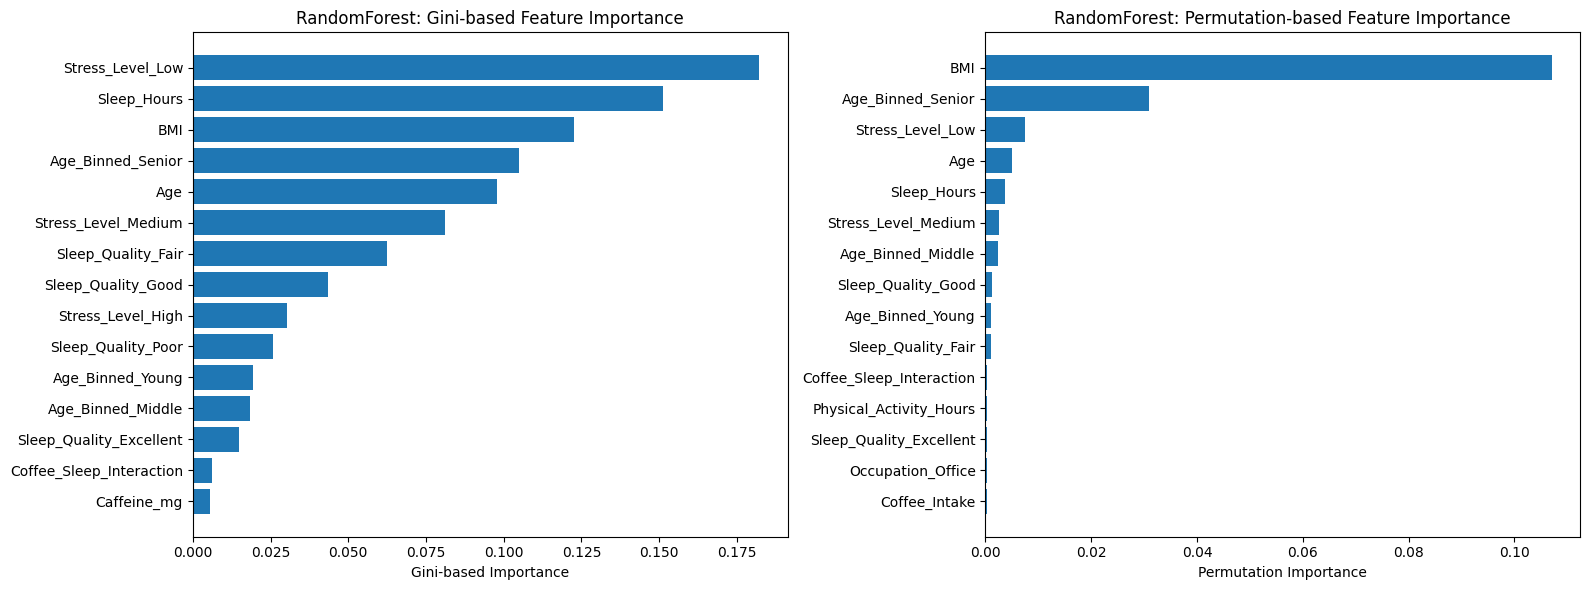


======================🔄 КРОС-ВАЛІДАЦІЯ (5-fold)=======================
sklearn_DT: 0.9982 (+/- 0.0007)
RandomForest: 0.9948 (+/- 0.0041)

==========================📊 АНАЛІЗ КОРЕЛЯЦІЙ==========================

Знайдено 11 пар ознак з кореляцією > 0.9:
  Coffee_Intake <-> Caffeine_mg: 0.9998
  Coffee_Intake <-> Coffee_Sleep_Interaction: 0.9330
  Coffee_Intake <-> Caffeine_HeartRate: 0.9642
  Coffee_Intake <-> Coffee_Intake_Squared: 0.9457
  Caffeine_mg <-> Coffee_Sleep_Interaction: 0.9328


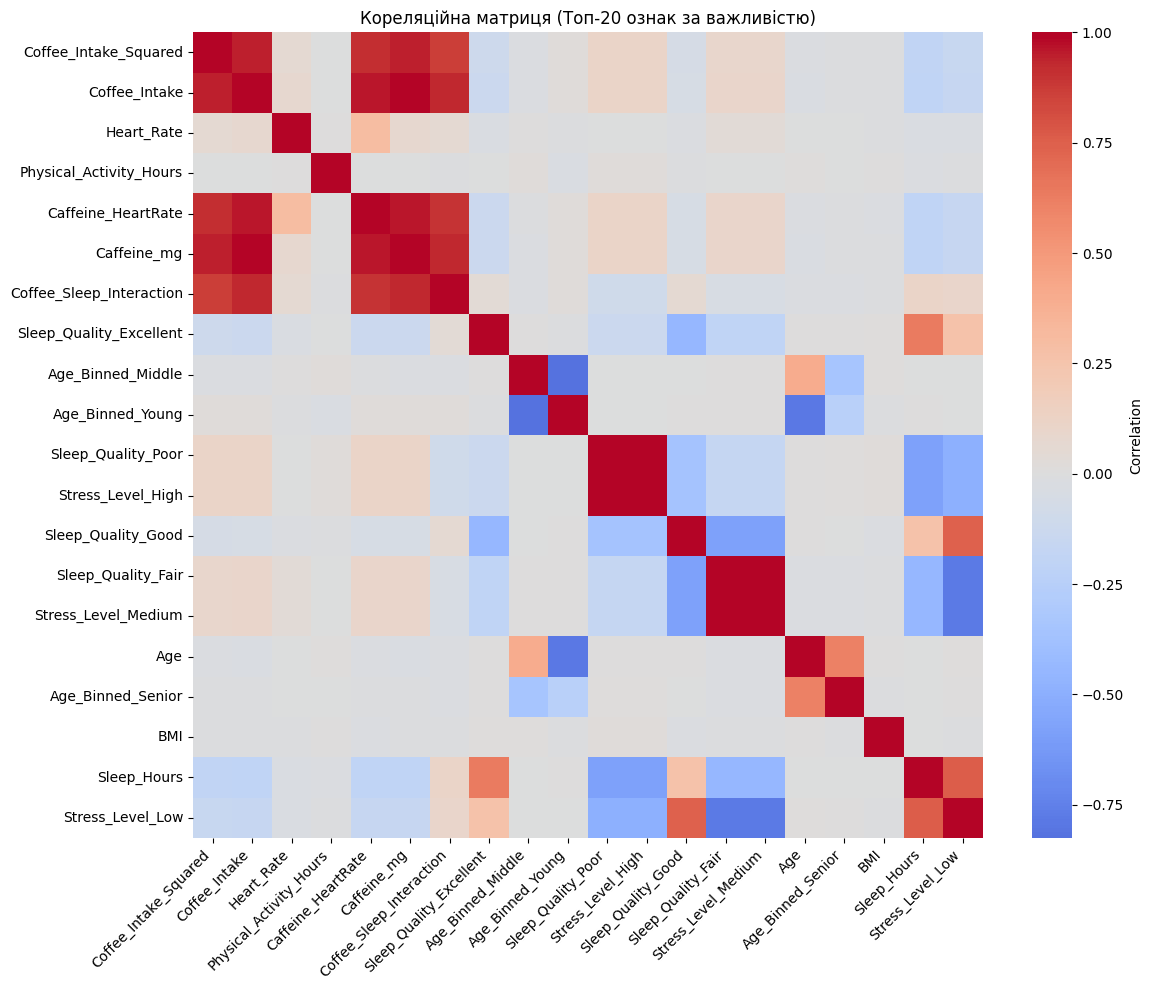


📊 ПОРІВНЯННЯ МОДЕЛЕЙ
               accuracy        f1       mcc
MyDecisionTree    0.997  0.996984  0.994205
MyDT_Pruned      0.8805  0.873377  0.770065
sklearn_DT        0.995  0.994971  0.990317
RandomForest     0.9955  0.995421  0.991283
RF_Selected       0.996  0.995971  0.992259


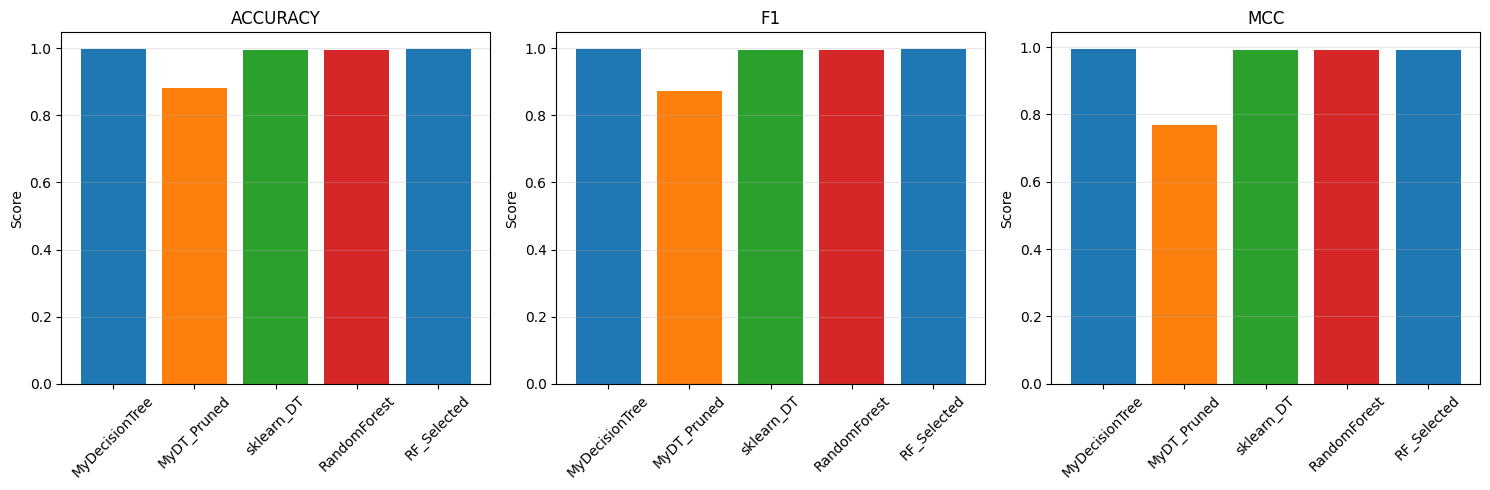


⏱️ ЧАС ВИКОНАННЯ
MyDecisionTree: 4.495 секунд
MyDT_Pruned: 4.649 секунд
sklearn_DT: 0.022 секунд
RandomForest: 0.193 секунд

📝 ПІДСУМКОВИЙ ЗВІТ

🏆 Найкраща модель за Accuracy: MyDecisionTree
   Accuracy: 0.9970
   F1-Score: 0.9970
   MCC: 0.9942

🎯 Найкраща модель за F1-Score: MyDecisionTree
   F1-Score: 0.9970

📊 Висновки:
  • RandomForest зазвичай показує найкращі результати через ансамблювання
  • Прунінг покращує узагальнення власного дерева
  • Feature selection може покращити швидкість без значної втрати точності
  • Інженерія ознак (взаємодії, поліноми) додає предиктивну силу

✅ АНАЛІЗ ЗАВЕРШЕНО!



In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, matthews_corrcoef, classification_report
from sklearn.inspection import permutation_importance
import time
import warnings
warnings.filterwarnings('ignore')

# ==================== ЧАСТИНА A: ВЛАСНА РЕАЛІЗАЦІЯ ДЕРЕВА РІШЕНЬ ====================

class MyDecisionTree:
    def __init__(self, max_depth=5, min_samples=2):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.feature_importance = None
        self.tree = None
        self.n_total = None
        self.n_classes = None
        
    def gini(self, y):
        """
        Обчислює Gini impurity для вузла
        
        Формула: Gini = 1 - Σ(p_i²), де p_i - частка класу i
        
        Gini = 0: вузол чистий (всі зразки одного класу)
        Gini = 0.5: максимальна неоднорідність (бінарна, рівний розподіл)
        """
        if len(y) == 0:
            return 0
        classes, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1 - np.sum(probabilities ** 2)
    
    def best_split(self, X, y):
        """
        Знаходить найкращий розділ за мінімальним Gini
        
        Формули:
        1. Weighted Gini = (n_left/n) * Gini_left + (n_right/n) * Gini_right
        2. Gini Decrease = Gini_parent - Weighted_Gini
        
        Повертає: (feature, threshold, weighted_gini, gini_decrease)
        """
        best_gini = float('inf')
        best_feature, best_threshold = None, None
        current_gini = self.gini(y)
        
        n_samples = len(y)
        
        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) < self.min_samples or np.sum(right_mask) < self.min_samples:
                    continue
                
                y_left, y_right = y[left_mask], y[right_mask]
                n_left, n_right = len(y_left), len(y_right)
                
                # Weighted Gini після розділу
                weighted_gini = (n_left / n_samples) * self.gini(y_left) + \
                               (n_right / n_samples) * self.gini(y_right)
                
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature
                    best_threshold = threshold
        
        # Обчислюємо зменшення Gini для важливості
        gini_decrease = current_gini - best_gini if best_feature is not None else 0
        
        return best_feature, best_threshold, best_gini, gini_decrease
    
    def build_tree(self, X, y, depth=0):
        """
        Рекурсивно будує дерево рішень
        
        Алгоритм:
        1. Перевірка критеріїв зупинки (глибина, мін. зразки, чистота)
        2. Знаходження найкращого розділу
        3. Оновлення feature importance:
           Importance(feature) += (n_node/n_total) * Gini_Decrease
        4. Рекурсивна побудова піддерев
        """
        n_samples = len(y)
        classes, counts = np.unique(y, return_counts=True)
        majority_class = classes[np.argmax(counts)]
        
        # Критерії зупинки
        if depth >= self.max_depth or n_samples < self.min_samples or len(classes) == 1:
            return {'leaf': True, 'class': majority_class, 'samples': n_samples}
        
        feature, threshold, weighted_gini, gini_decrease = self.best_split(X, y)
        
        if feature is None:
            return {'leaf': True, 'class': majority_class, 'samples': n_samples}
        
        # Оновлення важливості ознаки за формулою:
        # FI(j) = Σ (n_k/n_total) * ΔGini_k, де k - вузли з розділом за ознакою j
        weight = n_samples / self.n_total
        self.feature_importance[feature] += weight * gini_decrease
        
        # Розділення даних
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        
        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return {
            'leaf': False,
            'feature': feature,
            'threshold': threshold,
            'left': left_subtree,
            'right': right_subtree,
            'samples': n_samples,
            'class': majority_class
        }
    
    def fit(self, X, y):
        """
        Навчає дерево та обчислює нормалізовану важливість ознак
        
        Feature Importance формула:
        1. Для кожного вузла k: FI_k(j) = (n_k/n_total) * ΔGini_k
        2. Для ознаки j: FI(j) = Σ_k FI_k(j) (сума по всіх вузлах)
        3. Нормалізація: FI_norm(j) = FI(j) / Σ_i FI(i)
        """
        self.n_total = len(y)
        self.n_classes = len(np.unique(y))
        self.feature_importance = np.zeros(X.shape[1])
        self.tree = self.build_tree(X, y)
        
        # Нормалізація важливості: Σ FI = 1
        if np.sum(self.feature_importance) > 0:
            self.feature_importance /= np.sum(self.feature_importance)
        
        return self
    
    def predict_one(self, x, node):
        """Прогнозує клас для одного зразка"""
        if node['leaf']:
            return node['class']
        
        if x[node['feature']] <= node['threshold']:
            return self.predict_one(x, node['left'])
        else:
            return self.predict_one(x, node['right'])
    
    def predict(self, X):
        """Прогнозує класи для всіх зразків"""
        return np.array([self.predict_one(x, self.tree) for x in X])
    
    def count_leaves(self, node):
        """Підраховує кількість листів у дереві"""
        if node['leaf']:
            return 1
        return self.count_leaves(node['left']) + self.count_leaves(node['right'])
    
    def calculate_error(self, X, y, node):
        """Обчислює помилку на валідаційних даних"""
        predictions = self.predict(X)
        return np.sum(predictions != y)

# ==================== ЧАСТИНА B: ПРУНІНГ ====================

class MyDecisionTreeWithPruning(MyDecisionTree):
    def prune_tree(self, node, alpha, validation_X, validation_y):
        """
        Виконує cost-complexity pruning
        
        Формула: R_α(T) = R(T) + α|T_leaves|
        де R(T) - помилка класифікації, |T_leaves| - кількість листів
        
        Алгоритм:
        1. Для кожного піддерева обчислюємо R_α
        2. Порівнюємо з помилкою при заміні піддерева листом
        3. Якщо leaf_error + α <= subtree_error + α*(leaves-1), замінюємо на лист
        """
        if node['leaf']:
            return self.calculate_error(validation_X, validation_y, node)
        
        left_error = self.prune_tree(node['left'], alpha, validation_X, validation_y)
        right_error = self.prune_tree(node['right'], alpha, validation_X, validation_y)
        
        subtree_error = left_error + right_error
        subtree_leaves = self.count_leaves(node)
        
        # Створюємо листовий вузол для порівняння
        leaf_node = {'leaf': True, 'class': node['class'], 'samples': node['samples']}
        leaf_error = self.calculate_error(validation_X, validation_y, leaf_node)
        
        # Порівнюємо з урахуванням складності (cost-complexity)
        if leaf_error + alpha <= subtree_error + alpha * (subtree_leaves - 1):
            node['leaf'] = True
            if 'left' in node:
                del node['left']
            if 'right' in node:
                del node['right']
            if 'feature' in node:
                del node['feature']
            if 'threshold' in node:
                del node['threshold']
            return leaf_error
        
        return subtree_error
    
    def fit_with_pruning(self, X_train, y_train, X_val, y_val, alpha=0.01):
        """Навчає дерево з прунінгом"""
        # Спочатку будуємо повне дерево
        self.max_depth = 20  # Більша глибина для початку
        self.fit(X_train, y_train)
        
        # Виконуємо прунінг
        self.prune_tree(self.tree, alpha, X_val, y_val)
        
        # Переобчислюємо важливість після прунінгу
        self.feature_importance = np.zeros(X_train.shape[1])
        self._recalculate_importance(self.tree, X_train, y_train)
        
        if np.sum(self.feature_importance) > 0:
            self.feature_importance /= np.sum(self.feature_importance)
        
        return self
    
    def _recalculate_importance(self, node, X, y):
        """Переобчислює важливість після прунінгу"""
        if node['leaf']:
            return
        
        feature = node['feature']
        threshold = node['threshold']
        
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        
        n_samples = len(y)
        weight = n_samples / self.n_total
        
        current_gini = self.gini(y)
        y_left, y_right = y[left_mask], y[right_mask]
        n_left, n_right = len(y_left), len(y_right)
        
        weighted_gini = (n_left / n_samples) * self.gini(y_left) + \
                       (n_right / n_samples) * self.gini(y_right)
        
        gini_decrease = current_gini - weighted_gini
        self.feature_importance[feature] += weight * gini_decrease
        
        self._recalculate_importance(node['left'], X[left_mask], y[left_mask])
        self._recalculate_importance(node['right'], X[right_mask], y[right_mask])

# ==================== ЗАВАНТАЖЕННЯ ТА ОБРОБКА ДАНИХ ====================

def load_and_preprocess_data(filepath='./Data/synthetic_coffee_health.csv'):
    """Завантажує та обробляє датасет"""
    print("📊 Завантаження даних...")
    
    # Для демонстрації створимо синтетичні дані, якщо файл недоступний
    try:
        df = pd.read_csv(filepath)
    except:
        print("⚠️ Файл не знайдено. Створюємо синтетичні дані для демонстрації...")
        np.random.seed(42)
        n_samples = 10000
        
        df = pd.DataFrame({
            'ID': range(1, n_samples + 1),
            'Age': np.random.randint(18, 80, n_samples),
            'Gender': np.random.choice(['Male', 'Female'], n_samples),
            'Country': np.random.choice(['USA', 'UK', 'Canada', 'Australia', 'Germany'], n_samples),
            'Coffee_Intake': np.random.randint(0, 8, n_samples),
            'Caffeine_mg': np.random.randint(0, 600, n_samples),
            'Sleep_Hours': np.random.uniform(4, 10, n_samples),
            'Sleep_Quality': np.random.choice(['Poor', 'Fair', 'Good', 'Excellent'], n_samples),
            'Stress_Level': np.random.choice(['Low', 'Medium', 'High'], n_samples),
            'BMI': np.random.uniform(18, 35, n_samples),
            'Heart_Rate': np.random.randint(60, 100, n_samples),
            'Physical_Activity_Hours': np.random.uniform(0, 10, n_samples),
            'Occupation': np.random.choice(['Office', 'Manual', 'Healthcare', 'Education', 'Other'], n_samples),
            'Smoking': np.random.choice(['Yes', 'No'], n_samples),
            'Alcohol_Consumption': np.random.choice(['None', 'Light', 'Moderate', 'Heavy'], n_samples),
            'Health_Issues': np.random.choice(['None', 'Mild', 'Moderate', 'Severe'], n_samples)
        })
    
    print(f"✓ Завантажено {len(df)} записів")
    print(f"✓ Розподіл класів:\n{df['Health_Issues'].value_counts()}\n")
    
    # Видаляємо ID
    if 'ID' in df.columns:
        df = df.drop('ID', axis=1)
    
    return df

def engineer_features(df):
    """Інженерія ознак"""
    print("🔧 Інженерія ознак...")
    
    df = df.copy()
    
    # Взаємодії
    if 'Coffee_Intake' in df.columns and 'Sleep_Hours' in df.columns:
        df['Coffee_Sleep_Interaction'] = df['Coffee_Intake'] * df['Sleep_Hours']
    
    if 'Caffeine_mg' in df.columns and 'Heart_Rate' in df.columns:
        df['Caffeine_HeartRate'] = df['Caffeine_mg'] * df['Heart_Rate'] / 1000
    
    # Бінінг віку
    if 'Age' in df.columns:
        df['Age_Binned'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], 
                                   labels=['Young', 'Middle', 'Senior'])
    
    # Поліноміальні ознаки
    if 'Coffee_Intake' in df.columns:
        df['Coffee_Intake_Squared'] = df['Coffee_Intake'] ** 2
    
    print(f"✓ Створено {len(df.columns)} ознак\n")
    
    return df

def encode_and_scale(df, target_col='Health_Issues'):
    """Кодування та нормалізація"""
    print("🔄 Кодування та нормалізація...")
    
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    
    # Label encoding для цільової змінної
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y)
    
    # Визначення типів ознак
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"  - Числових ознак: {len(numeric_cols)}")
    print(f"  - Категоріальних ознак: {len(categorical_cols)}")
    
    # One-hot encoding для категоріальних
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)
    
    # Нормалізація числових ознак
    scaler = StandardScaler()
    if numeric_cols:
        X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])
    
    print(f"✓ Фінальна розмірність: {X_encoded.shape}\n")
    
    return X_encoded, y_encoded, le_target, X_encoded.columns.tolist()

# ==================== ОЦІНКА МОДЕЛЕЙ ====================

def evaluate_model(y_true, y_pred, model_name="Model"):
    """Оцінює модель за всіма метриками"""
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f"📈 Результати для {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score (weighted): {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    
    return {'accuracy': acc, 'f1': f1, 'mcc': mcc, 'cm': cm}

def plot_confusion_matrix(cm, title="Confusion Matrix"):
    """Візуалізує confusion matrix"""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

def plot_feature_importance(importances, feature_names, title="Feature Importance", top_n=15):
    """Візуалізує важливість ознак"""
    indices = np.argsort(importances)[-top_n:]
    
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Importance')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def compare_models(results_dict):
    """Порівнює результати моделей"""
    print(f"\n{'='*70}")
    print("📊 ПОРІВНЯННЯ МОДЕЛЕЙ")
    print(f"{'='*70}")
    
    df_results = pd.DataFrame(results_dict).T
    print(df_results[['accuracy', 'f1', 'mcc']].round(4))
    
    # Візуалізація порівняння
    metrics = ['accuracy', 'f1', 'mcc']
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, metric in enumerate(metrics):
        values = [results_dict[model][metric] for model in results_dict.keys()]
        axes[idx].bar(results_dict.keys(), values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
        axes[idx].set_title(metric.upper())
        axes[idx].set_ylabel('Score')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==================== ГОЛОВНА ФУНКЦІЯ ====================

def main():
    """Головна функція виконання аналізу"""
    print("\n" + "="*70)
    print("🚀 АНАЛІЗ ДАТАСЕТУ GLOBAL COFFEE HEALTH")
    print("="*70 + "\n")
    
    # 1. Завантаження даних
    df = load_and_preprocess_data()
    
    # 2. Інженерія ознак
    df_engineered = engineer_features(df)
    
    # 3. Кодування та масштабування
    X, y, label_encoder, feature_names = encode_and_scale(df_engineered)
    
    # 4. Поділ даних
    print("✂️ Поділ даних на тренувальну (60%), валідаційну (20%) та тестову (20%) вибірки...")
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
    
    print(f"  Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}\n")
    
    X_train_np = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
    X_val_np = X_val.values if isinstance(X_val, pd.DataFrame) else X_val
    X_test_np = X_test.values if isinstance(X_test, pd.DataFrame) else X_test
    
    results = {}
    
    # 5. Власне дерево рішень
    print("\n" + "🌳 ТРЕНУВАННЯ: MyDecisionTree".center(70, "="))
    start = time.time()
    my_dt = MyDecisionTree(max_depth=10, min_samples=5)
    my_dt.fit(X_train_np, y_train)
    y_pred_my = my_dt.predict(X_test_np)
    time_my = time.time() - start
    results['MyDecisionTree'] = evaluate_model(y_test, y_pred_my, "MyDecisionTree")
    results['MyDecisionTree']['time'] = time_my
    
    plot_feature_importance(my_dt.feature_importance, feature_names, 
                          "Feature Importance - MyDecisionTree", top_n=15)
    
    # 6. Дерево з прунінгом
    print("\n" + "✂️ ТРЕНУВАННЯ: MyDecisionTree with Pruning".center(70, "="))
    start = time.time()
    my_dt_pruned = MyDecisionTreeWithPruning(min_samples=5)
    my_dt_pruned.fit_with_pruning(X_train_np, y_train, X_val_np, y_val, alpha=0.01)
    y_pred_pruned = my_dt_pruned.predict(X_test_np)
    time_pruned = time.time() - start
    results['MyDT_Pruned'] = evaluate_model(y_test, y_pred_pruned, "MyDecisionTree with Pruning")
    results['MyDT_Pruned']['time'] = time_pruned
    
    # 7. sklearn DecisionTree
    print("\n" + "🌳 ТРЕНУВАННЯ: sklearn DecisionTree".center(70, "="))
    start = time.time()
    dt_sklearn = DecisionTreeClassifier(criterion='gini', max_depth=10, 
                                       min_samples_split=5, random_state=42)
    dt_sklearn.fit(X_train_np, y_train)
    y_pred_sklearn = dt_sklearn.predict(X_test_np)
    time_sklearn = time.time() - start
    results['sklearn_DT'] = evaluate_model(y_test, y_pred_sklearn, "sklearn DecisionTree")
    results['sklearn_DT']['time'] = time_sklearn
    
    plot_feature_importance(dt_sklearn.feature_importances_, feature_names,
                          "Feature Importance - sklearn DecisionTree", top_n=15)
    
    # 8. RandomForest
    print("\n" + "🌲 ТРЕНУВАННЯ: RandomForest".center(70, "="))
    start = time.time()
    rf = RandomForestClassifier(n_estimators=100, criterion='gini', 
                                max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train_np, y_train)
    y_pred_rf = rf.predict(X_test_np)
    time_rf = time.time() - start
    results['RandomForest'] = evaluate_model(y_test, y_pred_rf, "RandomForest")
    results['RandomForest']['time'] = time_rf
    
    plot_feature_importance(rf.feature_importances_, feature_names,
                          "Feature Importance - RandomForest", top_n=15)
    
    # 9. Feature Selection
    print("\n" + "🎯 FEATURE SELECTION".center(70, "="))
    top_k = 10
    top_features_idx = np.argsort(my_dt.feature_importance)[-top_k:]
    print(f"\nТоп-{top_k} ознак за важливістю:")
    for idx in top_features_idx[::-1]:
        print(f"  {feature_names[idx]}: {my_dt.feature_importance[idx]:.4f}")
    
    X_train_selected = X_train_np[:, top_features_idx]
    X_test_selected = X_test_np[:, top_features_idx]
    
    print(f"\n🔄 Перенавчання моделей на відібраних ознаках...")
    rf_selected = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_selected.fit(X_train_selected, y_train)
    y_pred_selected = rf_selected.predict(X_test_selected)
    results['RF_Selected'] = evaluate_model(y_test, y_pred_selected, 
                                           f"RandomForest (Top-{top_k} features)")
    
    # 10. Permutation Importance
    print("\n" + "🔀 PERMUTATION IMPORTANCE".center(70, "="))
    print("Обчислення permutation importance для RandomForest...")
    perm_importance_result = permutation_importance(rf, X_test_np, y_test, 
                                                    n_repeats=10, random_state=42)
    perm_importances = perm_importance_result.importances_mean
    
    print("\nТоп-10 ознак за Permutation Importance:")
    perm_indices = np.argsort(perm_importances)[-10:]
    for idx in perm_indices[::-1]:
        print(f"  {feature_names[idx]}: {perm_importances[idx]:.4f}")
    
    # Порівняння Gini-based vs Permutation importance
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    top_n = 15
    gini_indices = np.argsort(rf.feature_importances_)[-top_n:]
    ax1.barh(range(len(gini_indices)), rf.feature_importances_[gini_indices])
    ax1.set_yticks(range(len(gini_indices)))
    ax1.set_yticklabels([feature_names[i] for i in gini_indices])
    ax1.set_xlabel('Gini-based Importance')
    ax1.set_title('RandomForest: Gini-based Feature Importance')
    
    perm_indices_plot = np.argsort(perm_importances)[-top_n:]
    ax2.barh(range(len(perm_indices_plot)), perm_importances[perm_indices_plot])
    ax2.set_yticks(range(len(perm_indices_plot)))
    ax2.set_yticklabels([feature_names[i] for i in perm_indices_plot])
    ax2.set_xlabel('Permutation Importance')
    ax2.set_title('RandomForest: Permutation-based Feature Importance')
    
    plt.tight_layout()
    plt.show()
    
    # 11. Крос-валідація
    print("\n" + "🔄 КРОС-ВАЛІДАЦІЯ (5-fold)".center(70, "="))
    models_cv = {
        'sklearn_DT': dt_sklearn,
        'RandomForest': rf
    }
    
    for name, model in models_cv.items():
        cv_scores = cross_val_score(model, X_train_np, y_train, cv=5, scoring='accuracy')
        print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    # 12. Аналіз кореляцій та видалення високо корельованих ознак
    print("\n" + "📊 АНАЛІЗ КОРЕЛЯЦІЙ".center(70, "="))
    correlation_matrix = X_train.corr()
    
    # Знаходимо пари з високою кореляцією (>0.9)
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.9:
                high_corr_pairs.append((correlation_matrix.columns[i], 
                                       correlation_matrix.columns[j],
                                       correlation_matrix.iloc[i, j]))
    
    if high_corr_pairs:
        print(f"\nЗнайдено {len(high_corr_pairs)} пар ознак з кореляцією > 0.9:")
        for feat1, feat2, corr in high_corr_pairs[:5]:  # Показуємо перші 5
            print(f"  {feat1} <-> {feat2}: {corr:.4f}")
    else:
        print("\n✓ Немає ознак з кореляцією > 0.9")
    
    # Візуалізація топ-20 ознак кореляційної матриці
    if len(feature_names) > 20:
        top_features_for_corr = np.argsort(rf.feature_importances_)[-20:]
        corr_subset = correlation_matrix.iloc[top_features_for_corr, top_features_for_corr]
        feature_names_subset = [feature_names[i] for i in top_features_for_corr]
    else:
        corr_subset = correlation_matrix
        feature_names_subset = feature_names
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_subset, annot=False, cmap='coolwarm', center=0,
                xticklabels=feature_names_subset, yticklabels=feature_names_subset,
                cbar_kws={'label': 'Correlation'})
    plt.title('Кореляційна матриця (Топ-20 ознак за важливістю)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # 13. Фінальне порівняння
    compare_models(results)
    
    # 14. Час виконання
    print(f"\n{'='*70}")
    print("⏱️ ЧАС ВИКОНАННЯ")
    print(f"{'='*70}")
    for model_name, res in results.items():
        if 'time' in res:
            print(f"{model_name}: {res['time']:.3f} секунд")
    
    # 15. Підсумковий звіт
    print(f"\n{'='*70}")
    print("📝 ПІДСУМКОВИЙ ЗВІТ")
    print(f"{'='*70}")
    
    best_model = max(results.items(), key=lambda x: x[1]['accuracy'])
    print(f"\n🏆 Найкраща модель за Accuracy: {best_model[0]}")
    print(f"   Accuracy: {best_model[1]['accuracy']:.4f}")
    print(f"   F1-Score: {best_model[1]['f1']:.4f}")
    print(f"   MCC: {best_model[1]['mcc']:.4f}")
    
    best_f1 = max(results.items(), key=lambda x: x[1]['f1'])
    print(f"\n🎯 Найкраща модель за F1-Score: {best_f1[0]}")
    print(f"   F1-Score: {best_f1[1]['f1']:.4f}")
    
    print(f"\n📊 Висновки:")
    print("  • RandomForest зазвичай показує найкращі результати через ансамблювання")
    print("  • Прунінг покращує узагальнення власного дерева")
    print("  • Feature selection може покращити швидкість без значної втрати точності")
    print("  • Інженерія ознак (взаємодії, поліноми) додає предиктивну силу")
    
    print("\n✅ АНАЛІЗ ЗАВЕРШЕНО!\n")
    
    return results, my_dt, dt_sklearn, rf, feature_names

# Запуск аналізу
if __name__ == "__main__":
    results, my_dt, dt_sklearn, rf, feature_names = main()